# Principal component analysis

> A serious attempt at all the assignments is mandatory to grant access to the final exam. Refer to the course manual for more details (section *Overview* on Brightspace). 

> Please add today's topic to your knowledge graph.

**Learning goals:**
- Be able to implement PCA;
- Understand the properties of PCA;
- Understand the limitations of PCA;
- Understand how PCA can be used for dimensionality reduction.

**Solutions file:**

For this assignment, a solutions file will be released after the deadline.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

## (Optional) Exercise 1: applications of PCA
1. Find an interesting application of PCA and post a link to it (e.g., the blog post, article, podcast, video, etc.) on the Brightspace assignment forum of Week 03. Describe the application in several sentences. As the subject of your post, use a sensible title that explains the body: i.e., use a title like `group $<$number$>$: $<$your application$>$', where you fill in your group and the application you found.
1. Try to dig deep into your application. Please answer questions that come up on the forum. We might also ask you to answer questions that come up during the flipped-classroom session.
1. Interact with other groups by commenting on their posts. Elaborate on why you think their application is an interesting one (or not); would you want to know more about it (what and why)? Are there any parts that are unclear to you? Do you have any suggestions (e.g., other related sources of information)? Etc.

## Exercise 2: PCA overview
1. List and describe which computation steps are applied to the data when we do a Principal Component Analysis. You don't have to write the mathematical formulas but describe clearly what each step is doing. 

First we start with collecting and organising data (if that is not already provided). After we standardize the data so that there are no incredibly high numbers by changing Hz to Mhz for example. Then we calculate the covariance matrix between all the important variables. Here we can see what variables tend to increase together. Now we can find the eigenvectors which represent the directions where the data varies the most, which are the principal components. Now we can start reducing the data to the subspace with the highest variance with a 4 step plan. 

1. Translate all the datapoints onto the 0-point by removing the mean from all points.
2. Rotate the points so the eigenvectors are alligned with the X and Y axis.
3. Scale all the points according to the eigenvalues to make the graph correct.
4. Project every point to the first eigenvector so you reduce a dimension.





## Exercise 3: principal components
Below we provided a two-dimensional dataset $X$ of $N_{samples} \times D_{features}$, where $D_{features}=2$. The data are already zero-mean (requirement for PCA) and unlabeled. 
1. Compute the covariance matrix of this data;
1. Compute the eigenvalue decomposition of the covariance matrix to find the PCs;
1. Plot the data as a scatter plot;
1. Plot the PCs on this scatter plot. **Hint:** The directions of the PCs are given by the eigenvectors of the sample covariance matrix. Scale length of the PCs using the square root of the eigenvalues of sample covariance matrix.
1. Why do the PCs point in these directions?

**Important note**: Computational complexity of calculating the eigenvalue decomposition grows cubically with the number of features. Therefore, iterative approaches for computing the PCs are prefered when dealing with high dimensional data.

In [2]:
X = np.loadtxt('data/PCA_1.data')
N_samples = X.shape[0] # 200

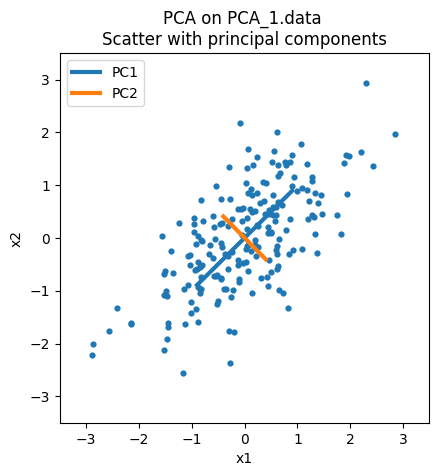

In [3]:
# Compute the covariance matrix of this data;
X_centered = X - X.mean(axis=0, keepdims=True)
cov = np.cov(X_centered.T, bias=False) 

# Compute the eigenvalue decomposition of the covariance matrix to find the PCs;
eigenvalues, eigenvectors = np.linalg.eig(cov)  

order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

explained_var_ratio = eigenvalues / eigenvalues.sum()

pc1 = eigenvectors[:, 0] * np.sqrt(eigenvalues[0])
pc2 = eigenvectors[:, 1] * np.sqrt(eigenvalues[1])

# Plot the data as a scatter plot/Plot the PCs on this scatter plot;
mean = X_centered.mean(axis=0)
plt.figure()
plt.scatter(X_centered[:,0], X_centered[:,1], s=12)
plt.plot([mean[0]-pc1[0], mean[0]+pc1[0]], [mean[1]-pc1[1], mean[1]+pc1[1]], linewidth=3, label="PC1")
plt.plot([mean[0]-pc2[0], mean[0]+pc2[0]], [mean[1]-pc2[1], mean[1]+pc2[1]], linewidth=3, label="PC2")
plt.gca().set_aspect('equal', 'box') #gca = get current axis
plt.xlim([-3.5,3.5])
plt.ylim([-3.5,3.5])
plt.title("PCA on PCA_1.data \nScatter with principal components")
plt.legend()
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

The reason these line are oriented this way is because these are the direction where the variance is the highest.

## Exercise 4: how outliers and scaling of the data affect PCA
The following dataset is similar to the one analyzed before, however it contains outliers. Explore the PCs again in the presence of outliers.
1. Like in exercise 2, compute and plot the PCs together with the scatter plot of the data;`
1. Why and how is PCA prone to fail in the presence of outliers?
1. How does the scaling of the features affect PCA? For example: Using cm instead of meters. **Hint:** PCA uses variance of the data as criterion to find the PCs.

In [4]:
X = np.loadtxt('data/PCA_2.data')
N_samples = X.shape[0]

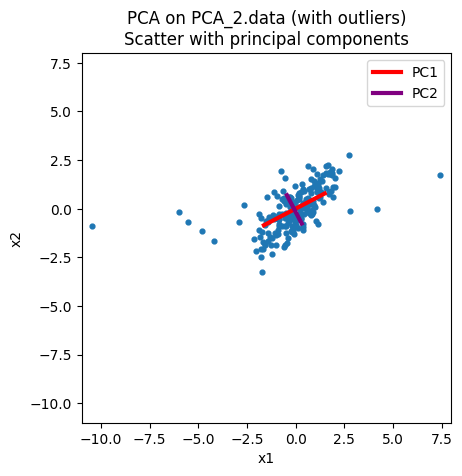

In [5]:
# Compute and plot the PCs together with the scatter plot of the data;
cov = np.cov(X.T, bias=False)
eigenvalues, eigenvectors = np.linalg.eig(cov)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

pc1 = eigenvectors[:, 0] * np.sqrt(eigenvalues[0])
pc2 = eigenvectors[:, 1] * np.sqrt(eigenvalues[1])

plt.figure()
plt.scatter(X[:,0], X[:,1], s=12)
mean = X.mean(axis=0)
plt.plot([mean[0]-pc1[0], mean[0]+pc1[0]], [mean[1]-pc1[1], mean[1]+pc1[1]], linewidth=3, label="PC1", color="red")
plt.plot([mean[0]-pc2[0], mean[0]+pc2[0]], [mean[1]-pc2[1], mean[1]+pc2[1]], linewidth=3, label="PC2", color="purple")
plt.gca().set_aspect('equal', 'box')
plt.xlim([-11,8])
plt.ylim([-11,8])
plt.title("PCA on PCA_2.data (with outliers)\nScatter with principal components")
plt.legend()
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


PCA is prone to outliers because the PC1 and PC2 lines are drawn towards the biggest difference in points. So an outlier might drag the biggest PC in that direction when the rest of the points are all close together and thus without a big variance.

The scaling of the features matters, because it would see a bigger difference in 50cm then 1m, even though technically a meter is a bigger difference then 50cm. It does not understand the meaning of the variables, just the numbers. That makes the variance look bigger than it actually is.

## Exercise 5: dimensionality reduction with PCA as preprocessing for classification problems (1/2)
In the following exercise, we will see how PCA can be used to reduce the dimensionality of a dataset as a pre-processing stage for a classification task.
1. For this dataset, plot the PCs together with the scatter plot of the labelled data like in exercise 3. Now, becuase we have labeled data of two classes, set the color of each of the points according to its class;
1. Project the data onto each of the PCs and plot the projection (e.g. as histogram);
1. Which of the PCs is more adequate to perform dimensionality reduction in the labelled dataset?

In [6]:
X = np.loadtxt('data/PCA_3.data')
y = np.loadtxt('data/PCA_3.labels')
N_samples = X.shape[0]

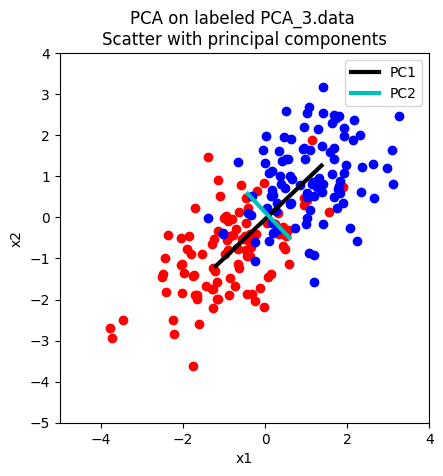

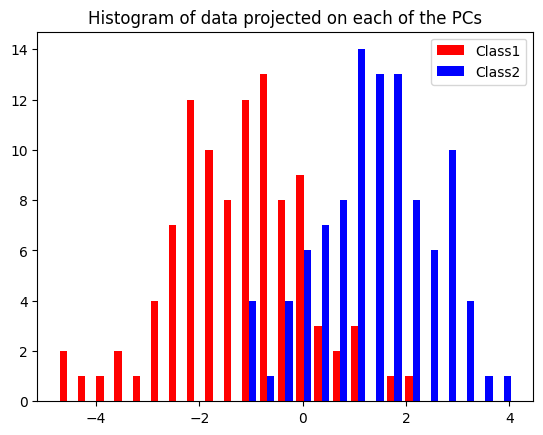

[3.15893206 0.54315674]


In [7]:
# Plot the PCs together with the scatter plot of the labelled data
cov = np.cov(X.T, bias=False)
eigenvalues, eigenvectors = np.linalg.eig(cov)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

pc1 = eigenvectors[:, 0] * np.sqrt(eigenvalues[0])
pc2 = eigenvectors[:, 1] * np.sqrt(eigenvalues[1])

plt.figure()
plt.scatter(X[y==0,0,], X[y==0,1,], color="red")
plt.scatter(X[y==1,0,], X[y==1,1,], color="blue")
mean = X.mean(axis=0)
plt.plot([mean[0]-pc1[0], mean[0]+pc1[0]], [mean[1]-pc1[1], mean[1]+pc1[1]], linewidth=3, label="PC1", color="k")
plt.plot([mean[0]-pc2[0], mean[0]+pc2[0]], [mean[1]-pc2[1], mean[1]+pc2[1]], linewidth=3, label="PC2", color="c")
plt.gca().set_aspect('equal', 'box')
plt.xlim([-5,4])
plt.ylim([-5,4])
plt.legend()
plt.title("PCA on labeled PCA_3.data \nScatter with principal components")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

# Project the data onto each of the PCs and plot the projection
projected_pc1 = X @ eigenvectors[:,0]
projected_pc2 = X @ eigenvectors[:,1]

plt.hist([projected_pc1 [y==0], projected_pc1[y==1]], bins=25, color=["red", "blue"], label=["Class1", "Class2"])
plt.title("Histogram of data projected on each of the PCs")
plt.legend()
plt.show()
                                                              
print(eigenvalues)

If you look at the eigenvalues of the two PC components, you can see that the variance of pc1 is way higher then in pc2. This makes it ideal to reduce the dimension onto pc1 so the data that gets lost is reduced as much as possible.

## Exercise 6: dimensionality reduction with PCA as preprocessing for classification problems (2/2)
This exercise is similar to exercise 5, but with a different dataset. For questions 1. and 2., re-use the same code as previously.
1. For this dataset, plot the PCs together with the scatter plot of the labelled data like in exercise 3. Set the color of each of the points according to its class;
1. Project the data onto each of the PCs and plot the projection (e.g. as histogram);
1. What is the most relevant PC in this case, given that the goal is to perform dimensionality reduction for a classification task? Please, also compare your answer to exercise 4.

In [8]:
X = np.loadtxt('data/PCA_4.data')
y = np.loadtxt('data/PCA_4.labels')
N_samples = X.shape[0]

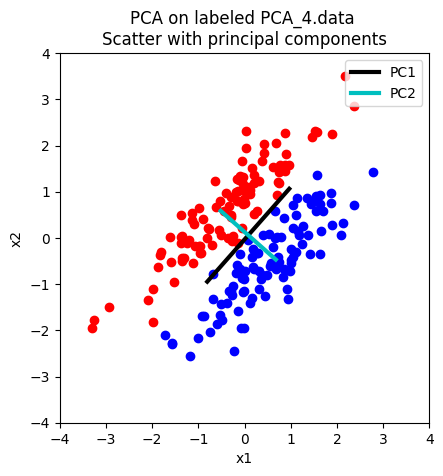

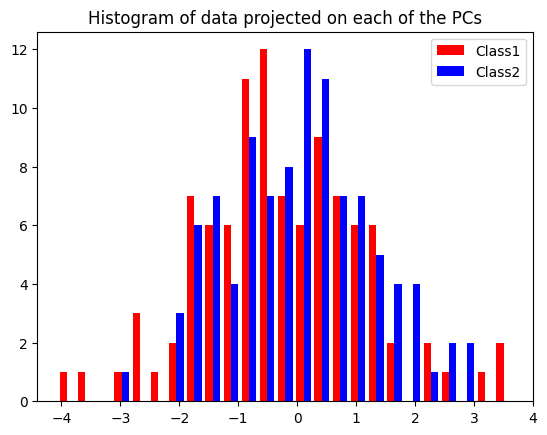

[1.79798406 0.63329142]


In [9]:
# Plot the PCs together with the scatter plot of the labelled data
cov = np.cov(X.T, bias=False)
eigenvalues, eigenvectors = np.linalg.eig(cov)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

pc1 = eigenvectors[:, 0] * np.sqrt(eigenvalues[0])
pc2 = eigenvectors[:, 1] * np.sqrt(eigenvalues[1])

plt.figure()
plt.scatter(X[y==0,0,], X[y==0,1,], color="red")
plt.scatter(X[y==1,0,], X[y==1,1,], color="blue")
mean = X.mean(axis=0)
plt.plot([mean[0]-pc1[0], mean[0]+pc1[0]], [mean[1]-pc1[1], mean[1]+pc1[1]], linewidth=3, label="PC1", color="k")
plt.plot([mean[0]-pc2[0], mean[0]+pc2[0]], [mean[1]-pc2[1], mean[1]+pc2[1]], linewidth=3, label="PC2", color="c")
plt.gca().set_aspect('equal', 'box')
plt.xlim([-4,4])
plt.ylim([-4,4])
plt.legend()
plt.title("PCA on labeled PCA_4.data \nScatter with principal components")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

# Project the data onto each of the PCs and plot the projection
projected_pc1 = X @ eigenvectors[:,0]
projected_pc2 = X @ eigenvectors[:,1]

plt.hist([projected_pc1 [y==0], projected_pc1[y==1]], bins=25, color=["red", "blue"], label=["Class1", "Class2"])
plt.title("Histogram of data projected on each of the PCs")
plt.legend()
plt.show()
                                                                      
print(eigenvalues)

PC1 is the most relevant, since it has the largest variance, and we want to maximize the variance. Compared to the previous exercise, this is the same answer. It is however less clear as the previous exercise, but pc1 still has a larger variance than pc2.

## Exercise 7: PCA for dimensionality reduction: Selecting the number of PC in a high dimensional dataset
In this exercise, we will explore the criteria that might be used to select the number of components for a dimensionality reduction task using PCA.
1. Compute the PCs;
1. Plot the eigenvalue spectrum (e.g., using the `plt.stem()` function);
1. By visually inspecting the eigenvalue spectrum of the covariance matrix, how many components do you think are necessary to achieve a good representation of the variance of the data? **Hint:** The magnitude of the eigenvalues represents the contribution of the corresponding PC to the variance of the data.


In [10]:
X = np.loadtxt('data/PCA_5.data')
N_samples = X.shape[0] # X = (1000,100)

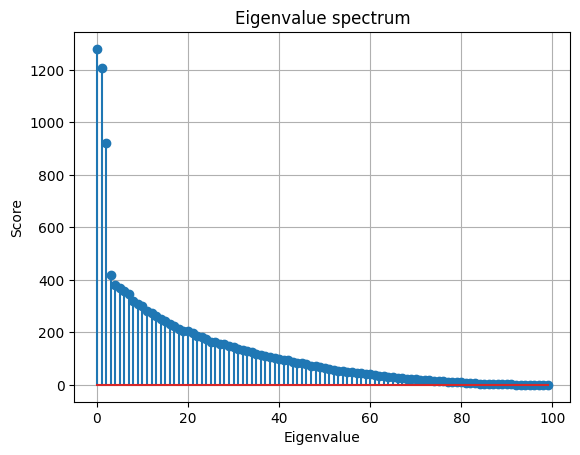

In [11]:
# Compute the PCs
cov = np.cov(X.T, bias=False)
eigenvalues, eigenvectors = np.linalg.eig(cov)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

pc = []
for i in range(eigenvalues.shape[0]): 
    pc.append(eigenvectors[:, i] * np.sqrt(eigenvalues[i]))
pc = np.array(pc) 
#print(pc.shape) (100,100)

# Plot the eigenvalue spectrum 
plt.figure()
plt.stem(eigenvalues)
plt.xlabel('Eigenvalue')
plt.ylabel('Score')
plt.title("Eigenvalue spectrum")
plt.grid()

3. By visually inspecting the eigenvalue spectrum of the covariance matrix, we can see that approximately 90% of the accumulated variance is reached around component 45. So about 45 components are necessary to achieve a good representation of the variance of the data.

## Exercise 8: PCA for dimensionality reduction: Selecting the number of PC in a high dimensional dataset
Visually inspecting the eigenvalue spectrum of the covariance matrix does not always provide a clear criterion for the selection of the number of relevant components (i.e., it is subjective). If that is the case, an alternative criterion might be used: Typically, the number of PC is selected so as to achieve approximately 90% of accumulated variance. 
**Note:** This this is only a rule of thumb, values of 95% or 99% are also often seen.

1. (Optional) Using the cumulative variance criterion, how many components should be selected for performing dimensionality reduction in the following dataset? **Hint:** The eigenvalues represent the variance explained by the corresponding PC.

In [12]:
X = np.loadtxt('data/PCA_6.data')
N_samples = X.shape[0]

In [13]:
# 1. Using the cumulative variance criterion, how many components should be selected for performing dimensionality reduction in the following dataset?
cov = np.cov(X.T, bias=False)
eigenvalues, eigenvectors = np.linalg.eig(cov)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]

eigenvalues_90 = sum(eigenvalues) * 0.9
total_sum = 0
for i in range(eigenvalues.shape[0]):
    if total_sum < eigenvalues_90:
        total_sum += eigenvalues[i]
    else: 
        print("We achieve 90% of the accumulated variance after Principal Component", i)
        break


We achieve 90% of the accumulated variance after Principal Component 49


## Exercise 0: Who did what?
Please provide a short description on who contributed what to your submission.

> Cas van Hanegem - Exercise 2,3,4
>
> Cas van Hanegem, Laurens Sloothaak, Jeroen Droog - Exercise 5,6,7,8 during workgroup